# Predicting student acadimic droupout and acadimic success 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split

## 1. Load and explore the heart disease dataset.  

In [2]:
data = pd.read_csv("data.csv", sep=';')

In [3]:
data

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [6]:
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [7]:
target_column = 'Target'

In [8]:
# DataFrame containing all the features
X_full = data.drop(columns=[target_column])
y = data[target_column]
print("Colonnes de X_full:", X_full.columns.tolist())
print("Valeurs uniques dans y:", y.unique())

Colonnes de X_full: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']
V

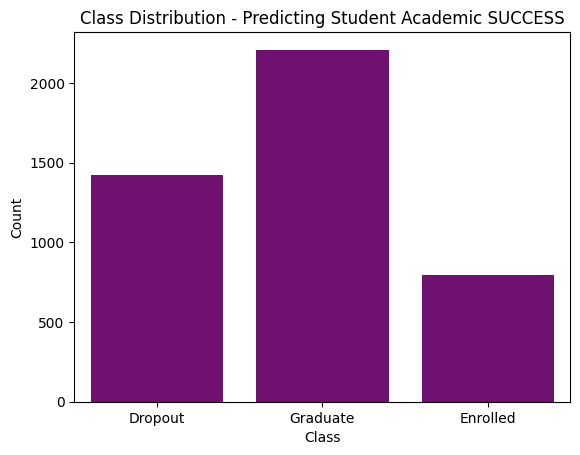

In [9]:
# Avec seaborn (sns)
sns.countplot(x=y, color='purple')
plt.title("Class Distribution - Predicting Student Academic SUCCESS")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

C:\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


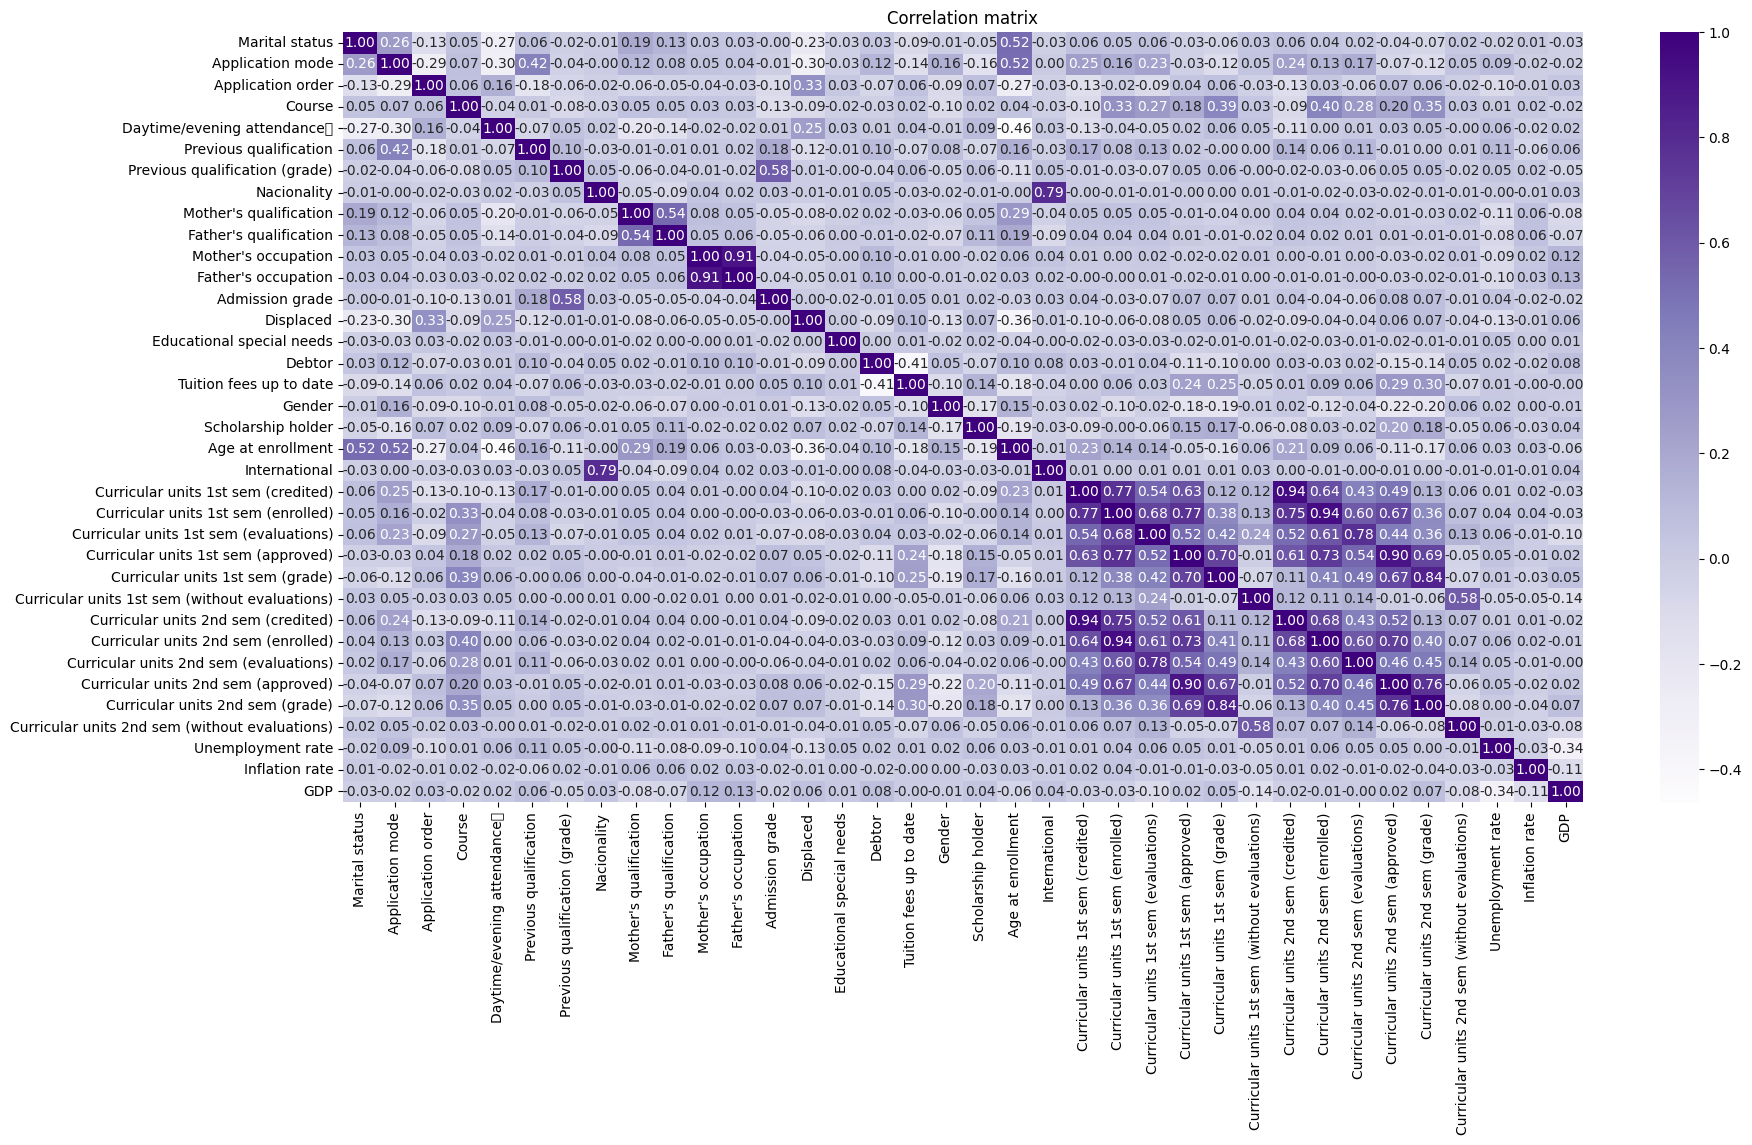

In [10]:
corr_matrix = X_full.corr()

plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, annot=True,cmap='Purples', fmt=".2f")
plt.title("Correlation matrix")
plt.show()

Nombre de composantes principales: 26
Shape du nouveau dataset: (4424, 26)


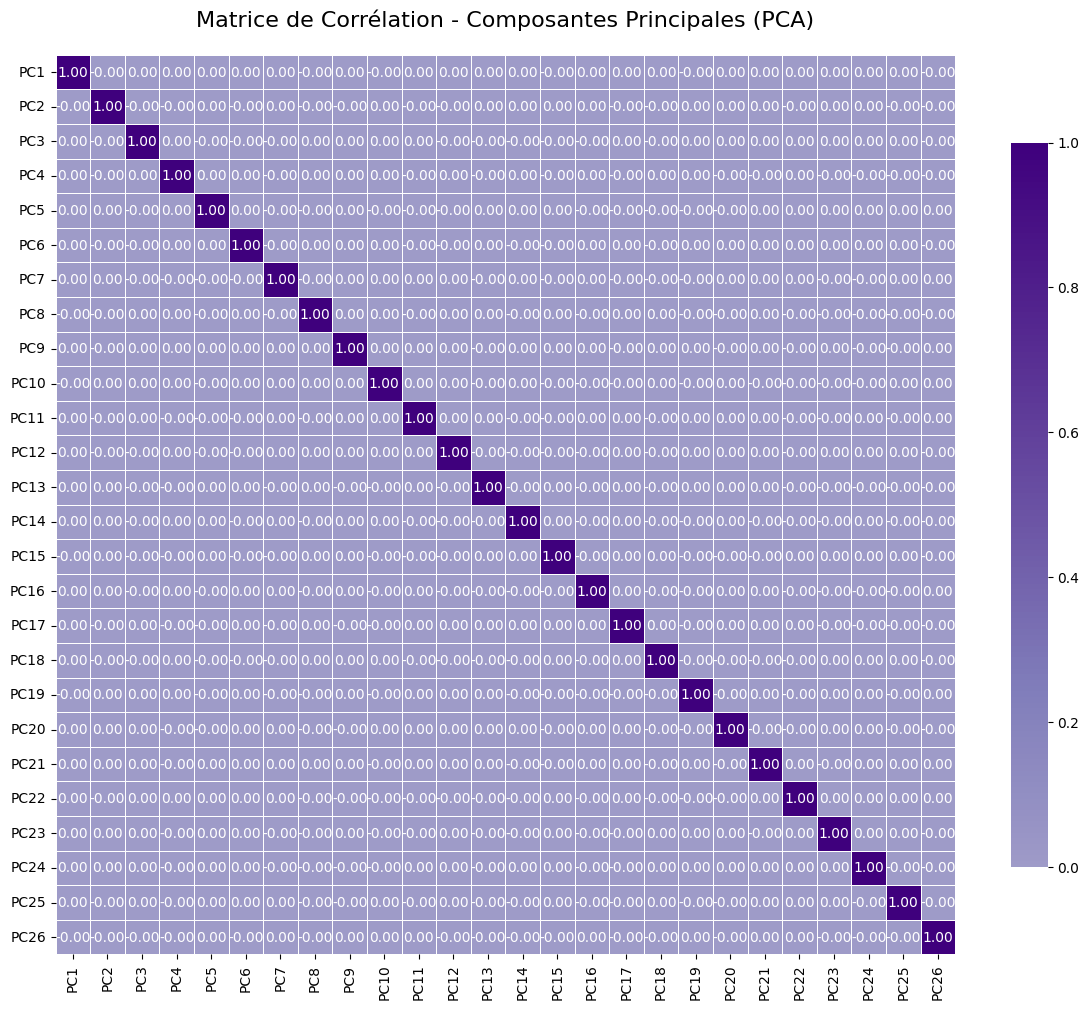


=== Statistiques de la Matrice de Corrélation ===
Valeur minimale: -0.0000
Valeur maximale (hors diagonal): 0.0000

Nombre de corrélations |r| > 0.5: 0
Nombre de corrélations |r| > 0.7: 0


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Appliquer PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

pca = PCA(n_components=0.95)  # ou le nombre que vous avez choisi
X_pca = pca.fit_transform(X_scaled)

# Créer un DataFrame avec les composantes principales
pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns)

print(f"Nombre de composantes principales: {X_pca.shape[1]}")
print(f"Shape du nouveau dataset: {X_pca_df.shape}")

# Calculer la matrice de corrélation
corr_matrix_pca = X_pca_df.corr()

# Visualiser la matrice de corrélation
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix_pca,
    annot=True,
    cmap='Purples',
    fmt=".2f",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matrice de Corrélation - Composantes Principales (PCA)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Afficher quelques statistiques
print("\n=== Statistiques de la Matrice de Corrélation ===")
print(f"Valeur minimale: {corr_matrix_pca.min().min():.4f}")
print(f"Valeur maximale (hors diagonal): {corr_matrix_pca.where(~np.eye(len(corr_matrix_pca), dtype=bool)).max().max():.4f}")
print(f"\nNombre de corrélations |r| > 0.5: {(abs(corr_matrix_pca) > 0.5).sum().sum() - len(corr_matrix_pca)}")
print(f"Nombre de corrélations |r| > 0.7: {(abs(corr_matrix_pca) > 0.7).sum().sum() - len(corr_matrix_pca)}")

In [13]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, precision_recall_fscore_support)

In [14]:
# les modeles a entrainer 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

### encoder the target feature 

In [15]:
# encoder le target 
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
print(f"\nClasses encodées: {dict(zip(class_names, range(len(class_names))))}")


Classes encodées: {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}


### train and test split 

In [16]:
# train and test 
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_encoded, 
    test_size=0.2, 
    random_state=42,
    stratify=y_encoded
)

In [17]:
print(f"\nTrain set: {X_train.shape[0]} instances ({X_train.shape[0]/len(X_pca)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} instances ({X_test.shape[0]/len(X_pca)*100:.1f}%)")


Train set: 3539 instances (80.0%)
Test set: 885 instances (20.0%)


In [18]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

### entrainement de model avec les algorithmes choisis 

In [21]:
# train phase 
results = []
for name, model in models.items():
    print(f"\nentrainement: {name}...")
    
    # entrainement
    model.fit(X_train, y_train)
    
    # prediction
    y_pred = model.predict(X_test)
    
    # metriques
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    # cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
    })
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-Score: {f1:.4f}")



entrainement: Logistic Regression...
  Accuracy: 0.7412
  F1-Score: 0.7253

entrainement: Random Forest...
  Accuracy: 0.7333
  F1-Score: 0.7068

entrainement: Gradient Boosting...
  Accuracy: 0.7243
  F1-Score: 0.7061

entrainement: SVM...
  Accuracy: 0.7435
  F1-Score: 0.7301

entrainement: KNN...
  Accuracy: 0.6712
  F1-Score: 0.6609

entrainement: Naive Bayes...
  Accuracy: 0.6463
  F1-Score: 0.6294

entrainement: Decision Tree...
  Accuracy: 0.6056
  F1-Score: 0.6065


### Comparaison des resultat 

In [22]:
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print("\n" + "="*60)
print("TABLEAU DE COMPARAISON")
print("="*60)
print(results_df.to_string(index=False))


TABLEAU DE COMPARAISON
              Model  Accuracy  Precision   Recall  F1-Score
                SVM  0.743503   0.730875 0.743503  0.730122
Logistic Regression  0.741243   0.720554 0.741243  0.725316
      Random Forest  0.733333   0.708037 0.733333  0.706817
  Gradient Boosting  0.724294   0.703125 0.724294  0.706089
                KNN  0.671186   0.654320 0.671186  0.660921
        Naive Bayes  0.646328   0.620353 0.646328  0.629403
      Decision Tree  0.605650   0.607542 0.605650  0.606526


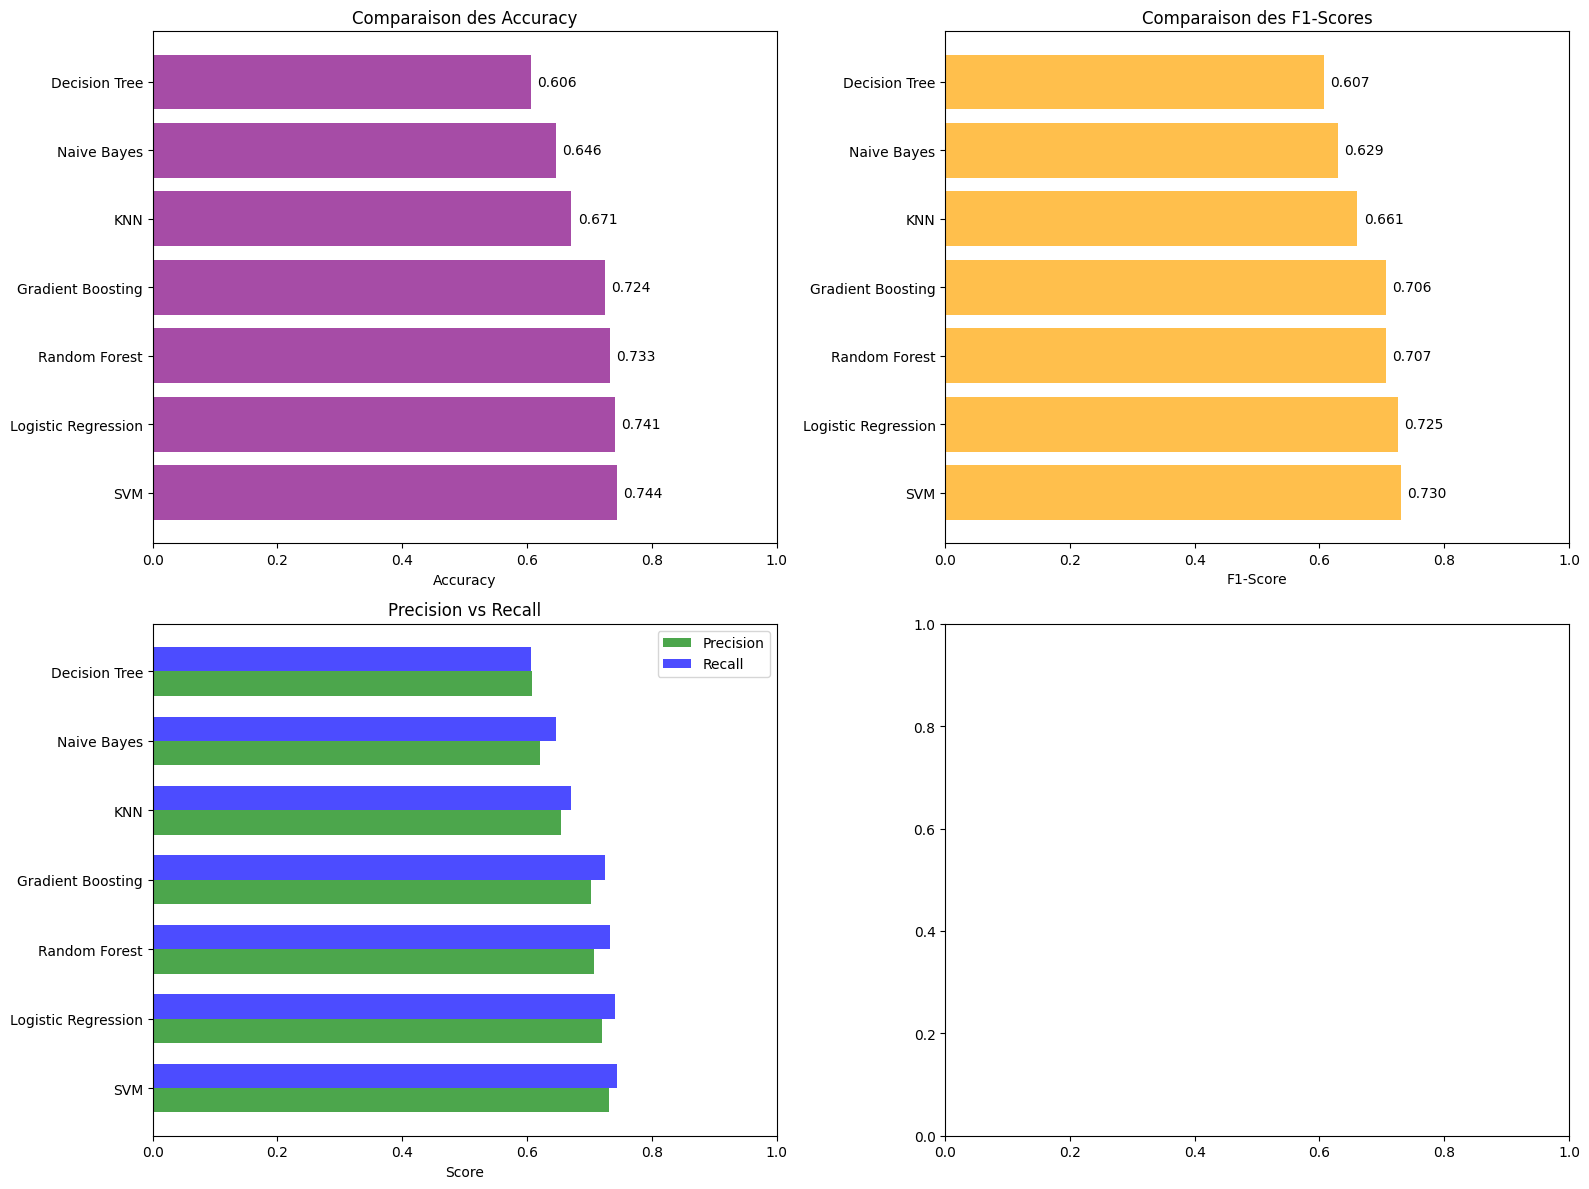

In [25]:
# Visualisation des résultats
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# accuracy
axes[0, 0].barh(results_df['Model'], results_df['Accuracy'], color='purple', alpha=0.7)
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_title('Comparaison des Accuracy')
axes[0, 0].set_xlim([0, 1])
for i, v in enumerate(results_df['Accuracy']):
    axes[0, 0].text(v + 0.01, i, f'{v:.3f}', va='center')

# f1-score
axes[0, 1].barh(results_df['Model'], results_df['F1-Score'], color='orange', alpha=0.7)
axes[0, 1].set_xlabel('F1-Score')
axes[0, 1].set_title('Comparaison des F1-Scores')
axes[0, 1].set_xlim([0, 1])
for i, v in enumerate(results_df['F1-Score']):
    axes[0, 1].text(v + 0.01, i, f'{v:.3f}', va='center')

# precision & recall
x = np.arange(len(results_df))
width = 0.35
axes[1, 0].barh(x - width/2, results_df['Precision'], width, label='Precision', color='green', alpha=0.7)
axes[1, 0].barh(x + width/2, results_df['Recall'], width, label='Recall', color='blue', alpha=0.7)
axes[1, 0].set_yticks(x)
axes[1, 0].set_yticklabels(results_df['Model'])
axes[1, 0].set_xlabel('Score')
axes[1, 0].set_title('Precision vs Recall')
axes[1, 0].legend()
axes[1, 0].set_xlim([0, 1])

plt.tight_layout()
plt.show()


### Conclusion


MEILLEUR MODÈLE: SVM

RAPPORT DE CLASSIFICATION:
              precision    recall  f1-score   support

     Dropout       0.83      0.71      0.77       284
    Enrolled       0.46      0.33      0.38       159
    Graduate       0.76      0.91      0.83       442

    accuracy                           0.74       885
   macro avg       0.69      0.65      0.66       885
weighted avg       0.73      0.74      0.73       885



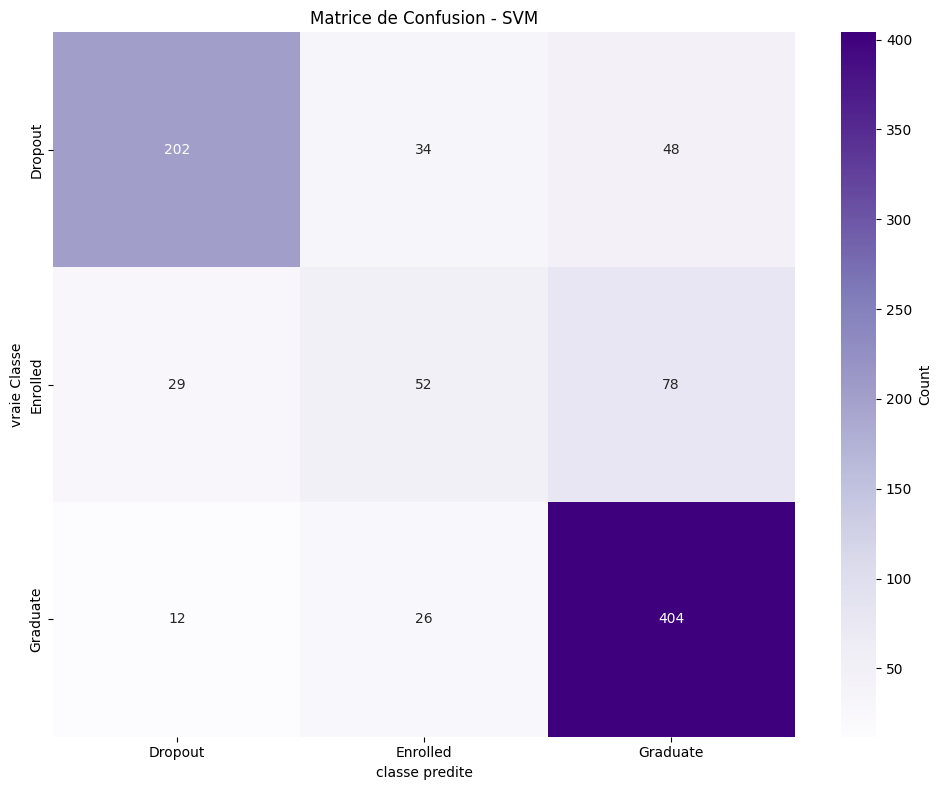

In [26]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print("\n" + "="*60)
print(f"MEILLEUR MODÈLE: {best_model_name}")
print("="*60)

# Ré-entraîner le meilleur modèle
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

# Rapport de classification
print("\nRAPPORT DE CLASSIFICATION:")
print(classification_report(y_test, y_pred_best, target_names=class_names))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title(f'Matrice de Confusion - {best_model_name}')
plt.ylabel('vraie Classe')
plt.xlabel('classe predite')
plt.tight_layout()
plt.show()